## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)


### Q1

In [33]:
df = pd.read_csv('/Users/clairicelou/Documents/DS3021/undergrad_ml_assignments/data/golub.csv', encoding='latin1')

df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [34]:
mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()

/var/folders/77/pq2rbbcj1vdb32s1d_503_b00000gn/T/ipykernel_69439/4282423095.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['outcome'] = df['cancer'].map(mapper)


,Samples,cancer,outcome
0,39,allB,0
1,40,allB,0
2,42,allB,0
3,47,allB,0
4,48,allB,0


In [35]:
y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)

print(f'Observations: {X.shape[0]}')
print(f'Genes used as predictors: {X.shape[1]}')

Observations: 72
Genes used as predictors: 7129


### Q2

In [36]:
ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
residuals_ols = y_hat_ols - y

print(f'OLS training MSE: {mse(y, y_hat_ols):.6g}')

OLS training MSE: 3.561e-30


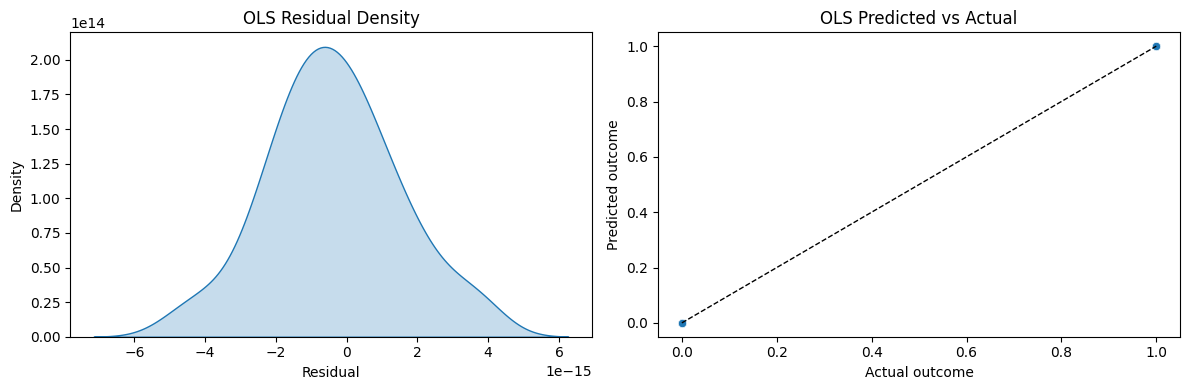

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat_ols, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.tight_layout()
plt.show()

The training MSE is basically zero, which means the model fits the training data almost perfectly. This makes sense because there are way more gene features than patient samples, so the model has enough flexibility to just memorize the data instead of actually learning patterns.

### Q3

In [38]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores

print('Fold MSE values:', cv_mse)
print(f'Mean CV MSE: {cv_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(cv_mse):.6f}')
print(f'Standard deviation: {cv_mse.std():.6f}')

Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


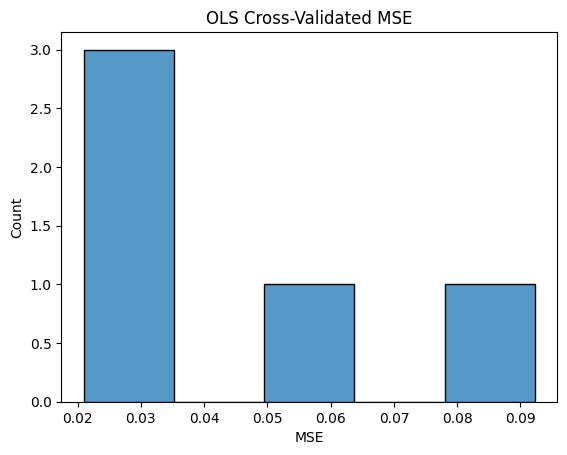

In [39]:
sns.histplot(cv_mse, bins=5)
plt.title('OLS Cross-Validated MSE')
plt.xlabel('MSE')
plt.show()

The big difference between the almost zero training error and the much higher cross validated MSE shows a high variance problem. The OLS model fits the training data really well but it doesn’t do as well on new data because it’s using way too many gene features compared to just 72 patients. The cross validation results show that the model isn’t generalizing as well as the training error makes it seem.

### Q4

In [40]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
selected_genes

Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059


['AF000560_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L13278_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27819_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M34344_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'U37055_rna1_s_at',
 'X07438_s_at',
 'M13690_s_at',
 'M26708_s_at',
 'M84371_rna1_s_at',
 'X12876_s_at',
 'U26312_s_at',
 'X85116_rna1_s_at',

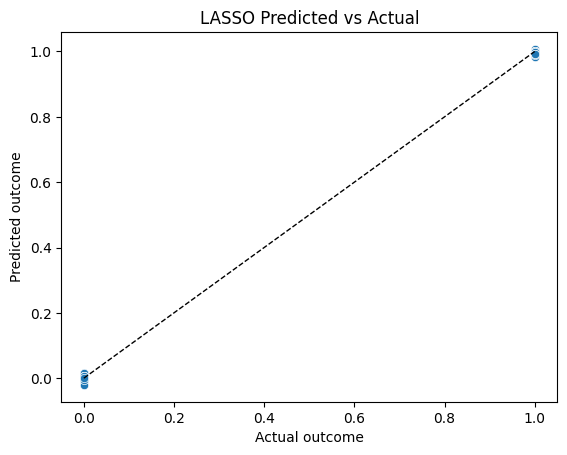

LASSO training MSE: 4.64279e-05


In [41]:
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual outcome')
plt.ylabel('Predicted outcome')
plt.show()

print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')

The LASSO keeps 80 genes and discards 7,049 genes from the original 7,129 predictors. The selected genes are:

`AF000560_at`, `AF002020_at`, `AF006087_at`, `D26579_at`, `D29956_at`, `D42043_at`, `D50840_at`, `D86982_at`, `HG2161-HT2231_at`, `J04101_at`, `J04164_at`, `L12723_at`, `L13848_at`, `L20941_at`, `M12759_at`, `M17754_at`, `M19507_at`, `M20902_at`, `M22960_at`, `M23197_at`, `M27891_at`, `M28713_at`, `M31994_at`, `M63138_at`, `M84526_at`, `M95178_at`, `M96326_rna1_at`, `M98539_at`, `U10868_at`, `U14588_at`, `U30828_at`, `U34877_at`, `U36621_cds2_at`, `U46751_at`, `U50136_rna1_at`, `U51127_at`, `U60062_at`, `U82313_at`, `U82759_at`, `U88666_at`, `U89942_at`, `X04143_at`, `X14789_at`, `X16706_at`, `X53331_at`, `X56741_at`, `X63753_at`, `X66533_at`, `X66867_cds1_at`, `X69111_at`, `X81479_at`, `X83378_at`, `X95735_at`, `X96698_at`, `Y00636_at`, `Y07604_at`, `Y07755_at`, `Y10207_at`, `Y12670_at`, `M96843_at`, `X58072_at`, `AC002477_s_at`, `L15326_s_at`, `X57351_at`, `K02777_s_at`, `U37055_rna1_s_at`, `U59632_s_at`, `X07438_s_at`, `M12959_s_at`, `M13690_s_at`, `M26708_s_at`, `M84371_rna1_s_at`, `X12876_s_at`, `M31211_s_at`, `U26312_s_at`, `X85116_rna1_s_at`, `HG4518-HT4921_r_at`, `L08010_at`, `U84388_at`, `X06318_at`.

### Q5

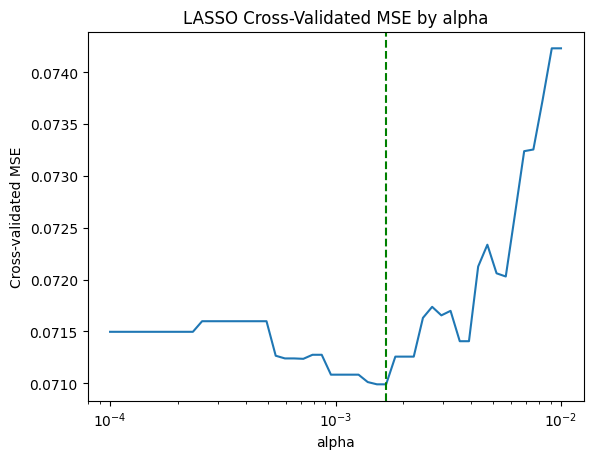

In [42]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()

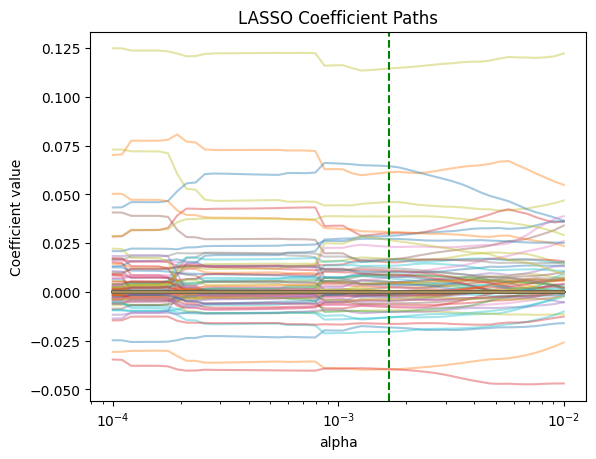

In [43]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

When α is large (on the left side of the plot), the model shrinks the coefficients too much and ends up underfitting. When α is very small (on the right side), too many coefficients are included, which leads to overfitting. The lowest expected error happens around α ≈ 0.0006551286.

### Q6

Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs almost perfectly on the training set because there are way more gene variables than patient observations so the model is flexible enough to basically memorize the training data. This gives it very low bias and almost zero training error, but it also makes it very sensitive to noise, leading to overfitting and high variance, so it doesn’t generalize well. LASSO improves predictions by adding a penalty that shrinks many coefficients to zero effectively selecting a smaller set of important genes. This increases bias a little but it reduces variance a lot which leads to better overall performance on new data.

### Q7

Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods work well in precision health because the data usually has many more variables (like genes) than observations. This can cause overfitting. Regularization reduces model complexity by shrinking coefficients, which lowers variance and improves predictions. Methods like LASSO also select the most important variables, making the model more interpretable and useful for identifying key genes. Regularization methods work well in precision health because there are a huge number of possible features especially when you consider not just individual genes but also interactions between them. This makes the feature space much larger than the number of observations which can lead to overfitting. Regularization methods like LASSO help by shrinking coefficients and selecting a smaller subset of important genes and interactions. This makes the model more manageable and improves prediction and is more practical for medical research/testing.

### Q8

What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Some risks of applying methods like the LASSO in precision health is that they focus on prediction, not what actually causes outcomes. The model may pick genes that are related to the outcome but not actually causing them. If interventions are based on these results, they may be ineffective or even harmful. Additionally, LASSO can be unstablbe in high dimensional settings, meaning that small changes in the data could lead to different genes being selected which reduce reliability. One big risk of using methods like LASSO in precision health is that they focus on prediction rather than causation. The genes selected by the model may be strongly associated with an outcome but they may not actually cause it. Since genes interact in complex ways and can’t easily be changed independently we can’t assume that targeting one gene will lead to the predicted effect. Interventions based only on these predictions could be ineffective or even harmful. Also, because LASSO is applied in high dimensional settings, the selected genes can sometimes change with small differences in the data which can make the results less reliable.